# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/mirl0w/Machine-Learning-Intern/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

In [1]:
import os, sys, subprocess
IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/flyrank-bih/flyrank-ml-internship-starter"
REPO_DIR = "flyrank-ml-internship-starter"

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)

import pandas as pd, numpy as np
df = pd.read_csv("data/raw/content_refresh_anonymized.csv")
df["is_declining_label"] = df["trend_direction"].str.lower().eq("down").astype(int)
print(df.shape)

(30000, 45)


In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


This queue ranks pages by model score, then maps each into a plain-language
action: refresh_content (stale + likely declining), rewrite_title_meta (visible
but weak CTR), review_priority (elevated risk, unclear cause), or monitor
(low priority). Each row carries a reason code so a reviewer sees WHY it's here,
not just a number.

In [2]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.tree import DecisionTreeClassifier

features = ["content_age_days", "days_since_last_update", "impressions_90d",
            "avg_position", "ctr", "word_count"]
X = df[features].replace([np.inf, -np.inf], np.nan).fillna(0)
y = df["is_declining_label"]

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=df["client_id"]))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

tree = DecisionTreeClassifier(max_depth=4, class_weight="balanced", random_state=42)
tree.fit(X_train, y_train)

results_df = df.iloc[test_idx].copy()
results_df["model_score"] = tree.predict_proba(X_test)[:,1]

def assign_action(row):
    if row["model_score"] >= 0.65 and row["days_since_last_update"] >= 180:
        return "stale_visible_page", "refresh_content"
    elif row["model_score"] >= 0.50 and row["ctr"] < 0.3:
        return "low_ctr_visible_page", "rewrite_title_meta"
    elif row["model_score"] >= 0.50:
        return "general_decline_risk", "review_priority"
    else:
        return "low_priority", "monitor"

results_df[["reason_code","action"]] = results_df.apply(
    lambda r: pd.Series(assign_action(r)), axis=1)

queue = results_df.sort_values("model_score", ascending=False)
print(queue["action"].value_counts())
queue[["content_id","model_score","reason_code","action"]].head(20)

action
monitor               4376
rewrite_title_meta    1351
review_priority        436
Name: count, dtype: int64


,content_id,model_score,reason_code,action
5,content_d4084a4bc775,0.688416,low_ctr_visible_page,rewrite_title_meta
29990,content_b7fa2d76e5ae,0.688416,low_ctr_visible_page,rewrite_title_meta
13,content_a5a2fbc76336,0.688416,low_ctr_visible_page,rewrite_title_meta
12953,content_a7da3b5b03ed,0.688416,low_ctr_visible_page,rewrite_title_meta
12973,content_f26254fad8aa,0.688416,low_ctr_visible_page,rewrite_title_meta
12997,content_54af84f1e737,0.688416,low_ctr_visible_page,rewrite_title_meta
12884,content_68c60a712a93,0.688416,low_ctr_visible_page,rewrite_title_meta
12909,content_5c4c5c953552,0.688416,low_ctr_visible_page,rewrite_title_meta
12923,content_461415b14c83,0.688416,low_ctr_visible_page,rewrite_title_meta
13025,content_1520bae94c77,0.688416,low_ctr_visible_page,rewrite_title_meta


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


Intended use: helps a content team prioritize which pages to review first,
under limited review capacity. This is decision-support only — it does not
edit or publish content itself.

Limits:
- Trained on a 30,000-row anonymized starter slice, not the full warehouse.
- The label (trend_direction == "down") is a snapshot proxy, not a validated
  future-window outcome.
- Cannot distinguish real decline from consolidation, seasonality, or SERP
  layout changes without manual review.
- Not validated on clients or content types outside this slice.

## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


Human review required for: every "refresh_content" and "rewrite_title_meta"
action, before any live change is made — the model flags candidates, a person
approves them.

No-go list — should NEVER be automated:
- Auto-publishing content edits from model score alone.
- Auto-deleting or de-indexing pages without human sign-off.
- Treating a high score as proof a refresh WILL cause recovery — that's a
  causal claim this data cannot support.
- Applying this model to a client with very little tracked history — too
  little data to trust the signals.

## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


Retrain triggers:
- Precision@50 on a newly-labeled holdout month drops meaningfully below
  today's observed number.
- A new content type or client segment appears that wasn't represented in
  training data.
- A noticeable site-wide shift in feature distributions (e.g. average CTR
  changes sharply across many clients at once, suggesting a SERP layout
  change rather than individual page issues).

Light monitoring: re-check Precision@K monthly against freshly observed
outcomes; re-run the leakage checklist whenever a new feature is added.

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


{'precision_at_20': 0.55, 'n_flagged_refresh': 0, 'n_flagged_rewrite': 1351, 'n_monitor_only': 4376}


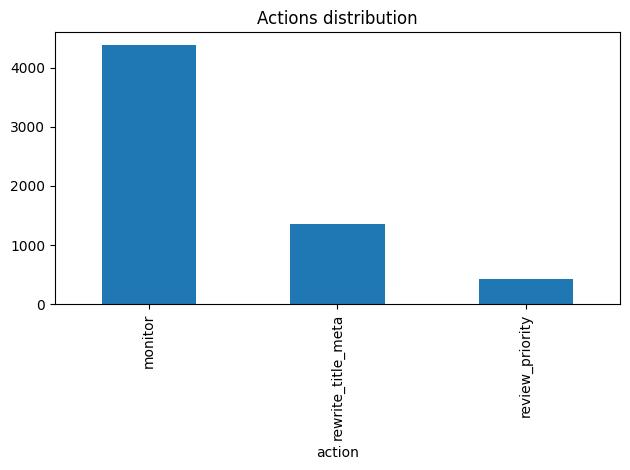

In [3]:
os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

queue[["content_id","model_score","reason_code","action"]].to_csv(
    "work/outputs/action_playbook_queue.csv", index=False)

import json
metrics = {
    "precision_at_20": float((queue["is_declining_label"].values[:20]).mean())
        if "is_declining_label" in queue.columns else None,
    "n_flagged_refresh": int((queue["action"]=="refresh_content").sum()),
    "n_flagged_rewrite": int((queue["action"]=="rewrite_title_meta").sum()),
    "n_monitor_only": int((queue["action"]=="monitor").sum()),
}
with open("work/outputs/playbook_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)
print(metrics)

import matplotlib.pyplot as plt
queue["action"].value_counts().plot(kind="bar", title="Actions distribution")
plt.tight_layout()
plt.savefig("work/figures/action_distribution.png")
plt.show()

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.